In [2]:
#Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_recall_curve, auc

import duckdb
from pathlib import Path
from xgboost import XGBClassifier
import optuna

In [ ]:
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [3]:
#Load data

SAML_CSV = Path("C:/Users/chris/Documents/Projects/Data/SAML-D.csv")

CFG = {
    "seed": 42,
    "ctr_threshold": 10_000,      # structuring reference threshold
    "struct_band": 0.10,          # "just under" = within 10% below threshold
    "windows_days": [1, 7, 30],
    "sample_accounts": 60_000,    # set None to use the full population
}
rng = np.random.default_rng(CFG["seed"])

con = duckdb.connect()  # in-memory; add a path arg to persist
pd.set_option("display.width", 160)
#df = pd.read_csv("C:/Users/chris/Documents/Projects/Data/SAML-D.csv")

In [4]:
con.execute(f"""
CREATE OR REPLACE VIEW raw AS
SELECT * FROM read_csv_auto('{SAML_CSV.as_posix()}', header=true, sample_size=200000)
""")

schema = con.execute("DESCRIBE raw").df()
print(schema, "\n")
print("rows:", con.execute("SELECT COUNT(*) FROM raw").fetchone()[0])

               column_name column_type null   key default extra
0                     Time        TIME  YES  None    None  None
1                     Date        DATE  YES  None    None  None
2           Sender_account      BIGINT  YES  None    None  None
3         Receiver_account      BIGINT  YES  None    None  None
4                   Amount      DOUBLE  YES  None    None  None
5         Payment_currency     VARCHAR  YES  None    None  None
6        Received_currency     VARCHAR  YES  None    None  None
7     Sender_bank_location     VARCHAR  YES  None    None  None
8   Receiver_bank_location     VARCHAR  YES  None    None  None
9             Payment_type     VARCHAR  YES  None    None  None
10           Is_laundering      BIGINT  YES  None    None  None
11         Laundering_type     VARCHAR  YES  None    None  None 



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

rows: 9504852


In [5]:
# Normalise to a single timestamp + stable txn id. Adjust the two casts if
# cell 1 showed Date/Time already parsed as DATE/TIME (then drop the CASTs).
con.execute("""
CREATE OR REPLACE VIEW txn AS
SELECT
    ROW_NUMBER() OVER (ORDER BY "Date", "Time") AS txn_id,
    (CAST("Date" AS DATE) + CAST("Time" AS TIME))  AS ts,
    CAST("Date" AS DATE)                           AS dt,
    CAST("Sender_account"   AS VARCHAR)            AS sender,
    CAST("Receiver_account" AS VARCHAR)            AS receiver,
    CAST("Amount" AS DOUBLE)                       AS amount,
    "Payment_currency"      AS pay_ccy,
    "Received_currency"     AS rcv_ccy,
    "Sender_bank_location"  AS sender_loc,
    "Receiver_bank_location" AS receiver_loc,
    "Payment_type"          AS pay_type,
    CAST("Is_laundering" AS INTEGER)               AS y,
    "Laundering_type"                              AS typology
FROM raw
""")

con.execute("SELECT * FROM txn LIMIT 5").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,txn_id,ts,dt,sender,receiver,amount,pay_ccy,rcv_ccy,sender_loc,receiver_loc,pay_type,y,typology
0,1,2022-10-07 10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,2,2022-10-07 10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,3,2022-10-07 10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,4,2022-10-07 10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,5,2022-10-07 10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


In [6]:
print(con.execute("""
SELECT COUNT(*) AS n, SUM(y) AS positives,
       100.0*SUM(y)/COUNT(*) AS pct_positive
FROM txn
""").df())

typo = con.execute("""
SELECT typology, y, COUNT(*) AS n, SUM(amount) AS total_amount
FROM txn GROUP BY 1,2 ORDER BY y DESC, n DESC
""").df()
print(typo.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

         n  positives  pct_positive
0  9504852     9873.0      0.103873


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

              typology  y       n  total_amount
           Structuring  1    1870  9.809655e+06
       Cash_Withdrawal  1    1334  2.058676e+05
          Deposit-Send  1     945  8.675891e+06
              Smurfing  1     932  2.612341e+06
        Layered_Fan_In  1     656  1.160257e+07
       Layered_Fan_Out  1     529  4.564555e+06
     Stacked Bipartite  1     506  4.921626e+06
  Behavioural_Change_1  1     394  1.922131e+06
             Bipartite  1     383  4.515827e+06
                 Cycle  1     382  1.070581e+07
                Fan_In  1     364  4.463610e+06
        Gather-Scatter  1     354  4.036811e+06
  Behavioural_Change_2  1     345  1.696055e+06
        Scatter-Gather  1     338  3.607138e+06
          Single_large  1     250  6.336835e+07
               Fan_Out  1     237  2.870652e+06
        Over-Invoicing  1      54  2.611431e+08
  Normal_Small_Fan_Out  0 3477717  1.635816e+10
        Normal_Fan_Out  0 2302220  2.322695e+10
         Normal_Fan_In  0 2104285  2.252

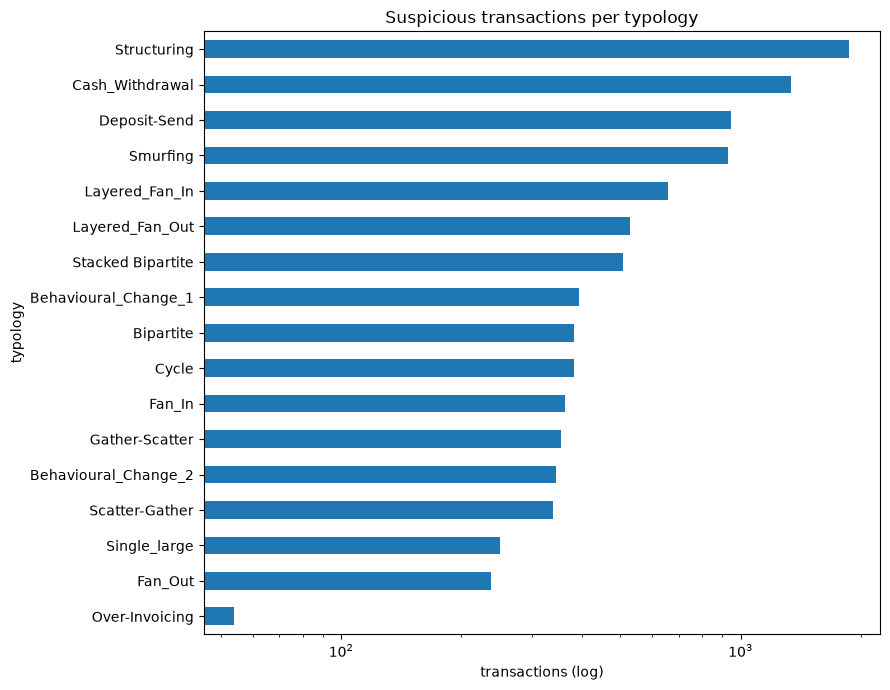

In [7]:
# How rare is the rarest typology? Anything in the low hundreds will be
# unlearnable individually -- we can report on this, but not performance.
susp = typo[typo.y == 1].sort_values("n")
ax = susp.plot.barh(x="typology", y="n", figsize=(9, 7), legend=False, logx=True)
ax.set_xlabel("transactions (log)"); ax.set_title("Suspicious transactions per typology")
plt.tight_layout(); plt.show()

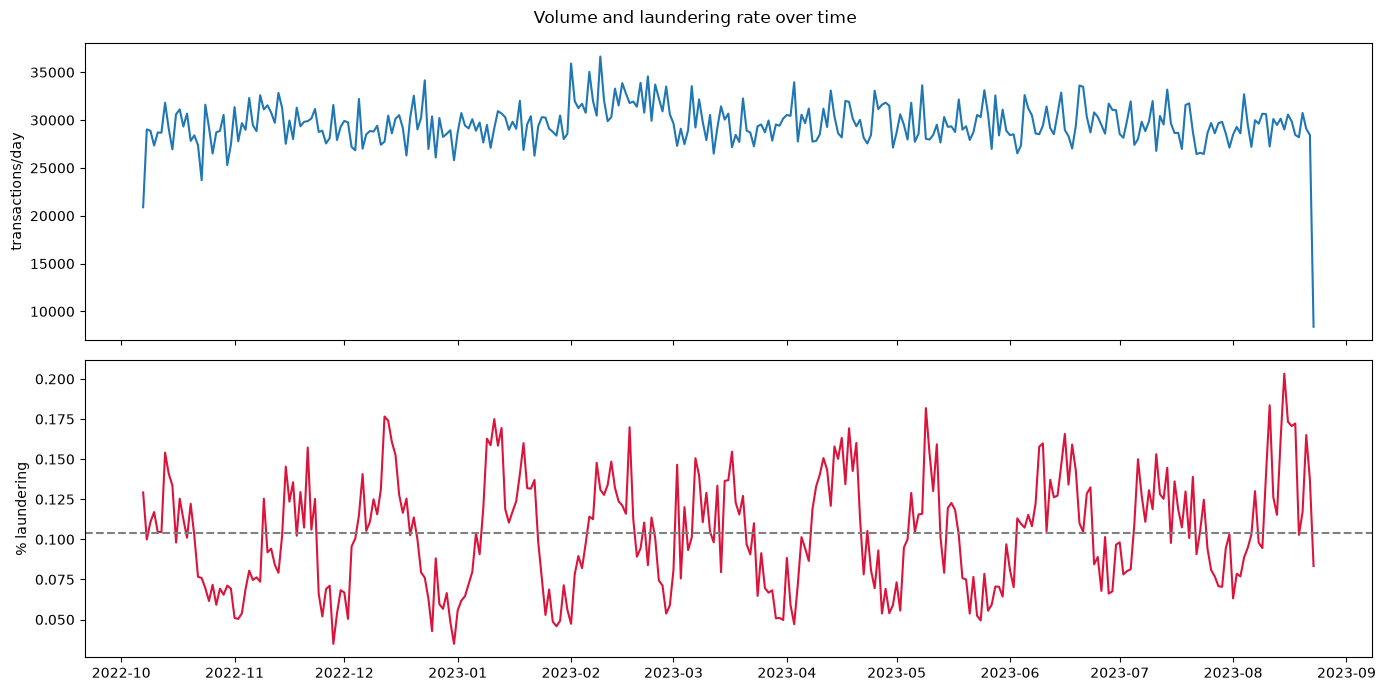

2022-10-07 00:00:00 -> 2023-08-23 00:00:00 | 321 days
proposed split: 2023-05-19 00:00:00


In [8]:
daily = con.execute("""
SELECT dt, COUNT(*) AS n, SUM(y) AS pos, 100.0*SUM(y)/COUNT(*) AS pct_pos
FROM txn GROUP BY 1 ORDER BY 1
""").df()

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax[0].plot(daily.dt, daily.n); ax[0].set_ylabel("transactions/day")
ax[1].plot(daily.dt, daily.pct_pos, color="crimson"); ax[1].set_ylabel("% laundering")
ax[1].axhline(daily.pct_pos.mean(), ls="--", c="grey")
plt.suptitle("Volume and laundering rate over time"); plt.tight_layout(); plt.show()

print(daily.dt.min(), "->", daily.dt.max(), "|", len(daily), "days")
# Chronological 70/30. Confirm the tail period isn't anomalous before committing.
SPLIT_DATE = daily.dt.quantile(0.7)
print("proposed split:", SPLIT_DATE)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   y  pct_just_under  pct_round_1k
0  0        0.047325      0.000009
1  1        0.036058      0.000000


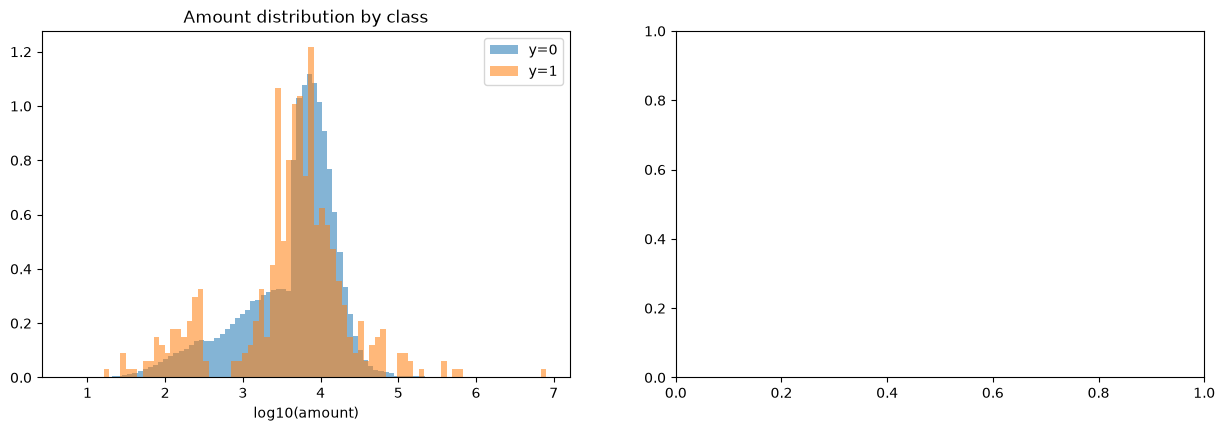

In [9]:
amt = con.execute("SELECT y, amount FROM txn USING SAMPLE 400000 ROWS").df()
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
for cls, sub in amt.groupby("y"):
    ax[0].hist(np.log10(sub.amount.clip(lower=1)), bins=80, alpha=.55,
               density=True, label=f"y={cls}")
ax[0].set_xlabel("log10(amount)"); ax[0].legend(); ax[0].set_title("Amount distribution by class")

near = con.execute(f"""
SELECT y,
       AVG(CASE WHEN amount BETWEEN {CFG['ctr_threshold']}*(1-{CFG['struct_band']})
                              AND {CFG['ctr_threshold']} THEN 1 ELSE 0 END) AS pct_just_under,
       AVG(CASE WHEN amount % 1000 = 0 THEN 1 ELSE 0 END) AS pct_round_1k
FROM txn GROUP BY 1
""").df()
print(near) 

In [10]:
def risk_table(col, min_n=500):
    return con.execute(f"""
        SELECT {col} AS value, COUNT(*) AS n, SUM(y) AS pos,
               100.0*SUM(y)/COUNT(*) AS pct_pos
        FROM txn GROUP BY 1 HAVING COUNT(*) >= {min_n}
        ORDER BY pct_pos DESC
    """).df()

for c in ["pay_type", "sender_loc", "receiver_loc", "pay_ccy"]:
    print(f"\n=== {c} ===")
    print(risk_table(c).head(12).to_string(index=False))


=== pay_type ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

          value       n    pos  pct_pos
   Cash Deposit  225206 1405.0 0.623873
Cash Withdrawal  300477 1334.0 0.443961
   Cross-border  933931 2628.0 0.281391
            ACH 2008807 1159.0 0.057696
    Credit card 2012909 1136.0 0.056436
     Debit card 2012103 1124.0 0.055862
         Cheque 2011419 1087.0 0.054041

=== sender_loc ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

      value     n  pos  pct_pos
    Morocco 18437 55.0 0.298313
     Mexico 17662 44.0 0.249122
Netherlands 16770 41.0 0.244484
      India 17596 42.0 0.238691
      Italy 18895 45.0 0.238158
    Germany 19259 43.0 0.223272
    Austria 18050 38.0 0.210526
      Japan 18468 38.0 0.205761
Switzerland 20503 41.0 0.199971
        USA 19027 36.0 0.189205
        UAE 20081 34.0 0.169314
     France 18702 31.0 0.165758

=== receiver_loc ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

      value     n   pos  pct_pos
    Nigeria 38272 251.0 0.655832
    Morocco 38704 253.0 0.653679
    Albania 38783 235.0 0.605936
        UAE 35897 195.0 0.543221
     Mexico 38385 197.0 0.513221
     Turkey 35586 177.0 0.497387
   Pakistan 38980 169.0 0.433556
Netherlands 37314 148.0 0.396634
    Austria 38844 154.0 0.396458
      India 36936 137.0 0.370912
      Italy 36517 131.0 0.358737
    Germany 38540 102.0 0.264660

=== pay_ccy ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

          value      n   pos  pct_pos
Moroccan dirham  25395  90.0 0.354400
         Dirham  27263  89.0 0.326450
    Swiss franc  27492  82.0 0.298269
   Indian rupee  24657  68.0 0.275784
   Mexican Peso  24852  68.0 0.273620
   Turkish lira  27996  73.0 0.260752
   Albanian lek  24778  64.0 0.258294
            Yen  25562  65.0 0.254284
      US dollar  26061  60.0 0.230229
          Naira  27143  62.0 0.228420
Pakistani rupee  27196  62.0 0.227975
           Euro 117164 260.0 0.221911


In [11]:
# Corridors -- the strongest single categorical signal in most AML data.
corr = con.execute("""
SELECT sender_loc || ' -> ' || receiver_loc AS corridor,
       COUNT(*) AS n, 100.0*SUM(y)/COUNT(*) AS pct_pos
FROM txn GROUP BY 1 HAVING COUNT(*) >= 1000
ORDER BY pct_pos DESC LIMIT 20
""").df()
print(corr.to_string(index=False))

# Cross-currency / cross-border prevalence by class
print(con.execute("""
SELECT y, AVG(CASE WHEN sender_loc <> receiver_loc THEN 1 ELSE 0 END) AS pct_xborder,
          AVG(CASE WHEN pay_ccy   <> rcv_ccy      THEN 1 ELSE 0 END) AS pct_xccy
FROM txn GROUP BY 1
""").df())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

         corridor     n  pct_pos
    UK -> Morocco 37146 0.659560
    UK -> Nigeria 36579 0.645179
    UK -> Albania 36788 0.578993
        UK -> UAE 34336 0.559180
     UK -> Mexico 36977 0.527355
     UK -> Turkey 34126 0.506945
   UK -> Pakistan 37595 0.425589
    UK -> Austria 37360 0.406852
UK -> Netherlands 35782 0.394053
      UK -> India 35533 0.363043
      UK -> Italy 34856 0.344274
    Morocco -> UK 16990 0.264862
    UK -> Germany 37056 0.261766
        UK -> USA 35410 0.228749
      UK -> Spain 35886 0.222928
Netherlands -> UK 14985 0.213547
UK -> Switzerland 34402 0.206383
      UK -> Japan 37130 0.204686
     UK -> France 37043 0.202467
    Austria -> UK 16812 0.202236


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   y  pct_xborder  pct_xccy
0  0     0.098084  0.113977
1  1     0.308417  0.370404


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

accounts: 855460
accounts touching >=1 suspicious txn: 7902
count    855460.000000
mean         22.221616
std          77.193688
min           1.000000
50%          12.000000
90%          17.000000
99%         522.000000
99.9%       810.000000
max        1498.000000
Name: n_txn, dtype: float64


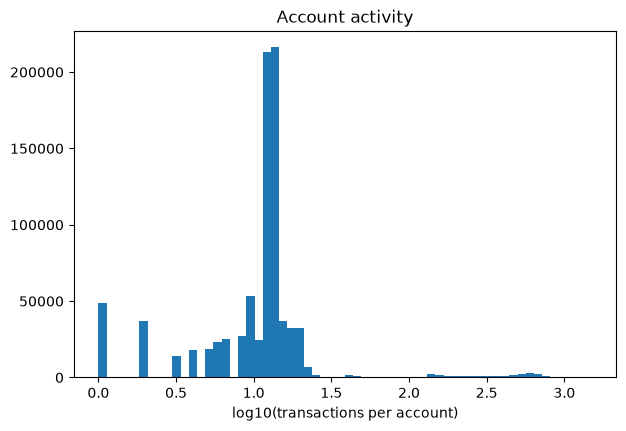

In [12]:
acct = con.execute("""
WITH legs AS (
    SELECT sender AS account, y FROM txn
    UNION ALL SELECT receiver, y FROM txn
)
SELECT account, COUNT(*) AS n_txn, SUM(y) AS n_susp
FROM legs GROUP BY 1
""").df()

print("accounts:", len(acct))
print("accounts touching >=1 suspicious txn:", (acct.n_susp > 0).sum())
print(acct.n_txn.describe(percentiles=[.5, .9, .99, .999]))

plt.figure(figsize=(7,4.5))
plt.hist(np.log10(acct.n_txn), bins=60)
plt.xlabel("log10(transactions per account)"); plt.title("Account activity"); plt.show()

In [13]:
susp_accounts = set(acct.loc[acct.n_susp > 0, "account"])
clean_pool    = acct.loc[acct.n_susp == 0, "account"].values

if CFG["sample_accounts"]:
    n_clean = max(0, CFG["sample_accounts"] - len(susp_accounts))
    keep = susp_accounts | set(rng.choice(clean_pool, size=min(n_clean, len(clean_pool)),
                                          replace=False))
else:
    keep = set(acct.account)

con.register("keep_accounts", pd.DataFrame({"account": list(keep)}))
con.execute("""
CREATE OR REPLACE TABLE txn_s AS
SELECT t.* FROM txn t
WHERE t.sender IN (SELECT account FROM keep_accounts)
   OR t.receiver IN (SELECT account FROM keep_accounts)
""")

print(con.execute("""
SELECT COUNT(*) n, SUM(y) pos, 100.0*SUM(y)/COUNT(*) pct FROM txn_s
""").df())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

         n     pos      pct
0  2458539  9873.0  0.40158


In [14]:
con.execute("""
CREATE OR REPLACE TABLE legs AS
SELECT txn_id, ts, sender AS account, receiver AS counterparty,
       'OUT' AS direction, amount, pay_type, sender_loc AS own_loc,
       receiver_loc AS cp_loc, y
FROM txn_s
UNION ALL
SELECT txn_id, ts, receiver, sender,
       'IN', amount, pay_type, receiver_loc, sender_loc, y
FROM txn_s
""")
con.execute("CREATE INDEX idx_legs ON legs(account, ts)")
print(con.execute("SELECT COUNT(*) FROM legs").fetchone()[0], "legs")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

4917078 legs


In [15]:
win_sql = []
for d in CFG["windows_days"]:
    win_sql += [
        f"COUNT(*)   OVER w{d} AS cnt_{d}d",
        f"SUM(amount) OVER w{d} AS sum_{d}d",
        f"AVG(amount) OVER w{d} AS avg_{d}d",
        f"MAX(amount) OVER w{d} AS max_{d}d",
    ]
win_defs = ", ".join(
    f"w{d} AS (PARTITION BY account, direction ORDER BY ts "
    f"RANGE BETWEEN INTERVAL {d} DAY PRECEDING AND CURRENT ROW)"
    for d in CFG["windows_days"]
)

con.execute(f"""
CREATE OR REPLACE TABLE leg_feat AS
SELECT txn_id, account, direction, ts, amount,
       {", ".join(win_sql)},
       -- dormancy: seconds since this account's previous activity
       date_diff('second',
                 LAG(ts) OVER (PARTITION BY account, direction ORDER BY ts),
                 ts) AS secs_since_prev,
       -- behavioural change: amount vs the account's own trailing profile
       AVG(amount) OVER (PARTITION BY account, direction ORDER BY ts
                         ROWS BETWEEN 20 PRECEDING AND 1 PRECEDING) AS trail_avg_20,
       STDDEV_SAMP(amount) OVER (PARTITION BY account, direction ORDER BY ts
                         ROWS BETWEEN 20 PRECEDING AND 1 PRECEDING) AS trail_std_20
FROM legs
WINDOW {win_defs}
""")
con.execute("SELECT * FROM leg_feat LIMIT 5").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,txn_id,account,direction,ts,amount,cnt_1d,sum_1d,avg_1d,max_1d,cnt_7d,sum_7d,avg_7d,max_7d,cnt_30d,sum_30d,avg_30d,max_30d,secs_since_prev,trail_avg_20,trail_std_20
0,5450533,9745312273,OUT,2023-04-08 11:21:40,11437.70,51,464011.56,9098.265882,20597.54,59,481764.44,8165.498983,20597.54,77,568368.59,7381.410260,20597.54,28,7983.1035,3093.569310
1,5450685,9745312273,OUT,2023-04-08 11:28:26,4661.05,52,468672.61,9012.934808,20597.54,60,486425.49,8107.091500,20597.54,78,573029.64,7346.533846,20597.54,406,8322.7465,3080.638493
2,5450822,9745312273,OUT,2023-04-08 11:34:13,4614.44,53,473287.05,8929.944340,20597.54,61,491039.93,8049.834918,20597.54,79,577644.08,7311.950380,20597.54,347,8025.7435,3135.276386
3,5451047,9745312273,OUT,2023-04-08 11:42:20,4666.75,54,477953.80,8850.996296,20597.54,62,495706.68,7995.269032,20597.54,80,582310.83,7278.885375,20597.54,487,8025.0770,3136.038073
4,5451084,9745312273,OUT,2023-04-08 11:43:53,6115.08,55,484068.88,8801.252364,20597.54,63,501821.76,7965.424762,20597.54,81,588425.91,7264.517407,20597.54,93,8014.5105,3147.534525


In [16]:
FAN_WINDOW = 7
con.execute(f"""
CREATE OR REPLACE TABLE fan_feat AS
SELECT l.txn_id, l.direction,
       COUNT(DISTINCT l2.counterparty) AS n_cp_{FAN_WINDOW}d,
       COUNT(*)                        AS n_txn_{FAN_WINDOW}d
FROM legs l
JOIN legs l2
  ON l2.account = l.account
 AND l2.direction = l.direction
 AND l2.ts <= l.ts
 AND l2.ts >  l.ts - INTERVAL {FAN_WINDOW} DAY
GROUP BY 1, 2
""")
print(con.execute("SELECT * FROM fan_feat LIMIT 5").df())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   txn_id direction  n_cp_7d  n_txn_7d
0  797375       OUT        1        12
1  796796       OUT        1        12
2  797265       OUT        1         1
3  824530       OUT        1        12
4  800196       OUT        1         2


In [17]:
con.execute(f"""
CREATE OR REPLACE TABLE features AS
WITH s AS (SELECT * FROM leg_feat WHERE direction = 'OUT'),
     r AS (SELECT * FROM leg_feat WHERE direction = 'IN'),
     sf AS (SELECT txn_id, n_cp_7d AS snd_n_cp_7d FROM fan_feat WHERE direction='OUT'),
     rf AS (SELECT txn_id, n_cp_7d AS rcv_n_cp_7d FROM fan_feat WHERE direction='IN')
SELECT
    t.txn_id, t.ts, t.dt, t.y, t.typology,
    t.amount, t.pay_type, t.pay_ccy, t.rcv_ccy, t.sender_loc, t.receiver_loc,

    -- transaction-intrinsic
    log10(t.amount + 1)                                     AS log_amount,
    CASE WHEN t.sender_loc <> t.receiver_loc THEN 1 ELSE 0 END AS is_xborder,
    CASE WHEN t.pay_ccy    <> t.rcv_ccy      THEN 1 ELSE 0 END AS is_xccy,
    CASE WHEN t.amount % 1000 = 0 THEN 1 ELSE 0 END          AS is_round_1k,
    CASE WHEN t.amount BETWEEN {CFG['ctr_threshold']}*(1-{CFG['struct_band']})
                           AND {CFG['ctr_threshold']} THEN 1 ELSE 0 END AS is_just_under_ctr,
    hour(t.ts)                                              AS hour_of_day,
    CASE WHEN dayofweek(t.ts) IN (0,6) THEN 1 ELSE 0 END     AS is_weekend,

    -- sender-side velocity
    s.cnt_1d AS snd_cnt_1d, s.cnt_7d AS snd_cnt_7d, s.cnt_30d AS snd_cnt_30d,
    s.sum_7d AS snd_sum_7d, s.max_7d AS snd_max_7d,
    s.secs_since_prev AS snd_dormancy,
    (t.amount - s.trail_avg_20) / NULLIF(s.trail_std_20, 0) AS snd_amount_z,

    -- receiver-side velocity
    r.cnt_1d AS rcv_cnt_1d, r.cnt_7d AS rcv_cnt_7d, r.cnt_30d AS rcv_cnt_30d,
    r.sum_7d AS rcv_sum_7d,
    r.secs_since_prev AS rcv_dormancy,
    (t.amount - r.trail_avg_20) / NULLIF(r.trail_std_20, 0) AS rcv_amount_z,

    -- graph shape
    sf.snd_n_cp_7d, rf.rcv_n_cp_7d,
    sf.snd_n_cp_7d::DOUBLE / NULLIF(s.cnt_7d, 0) AS snd_cp_ratio,

    -- pass-through / mule: inflow vs outflow balance on the receiver
    r.sum_7d / NULLIF(
        (SELECT sum_7d FROM leg_feat lf
         WHERE lf.txn_id = t.txn_id AND lf.direction = 'OUT'), 0) AS rcv_flow_ratio

FROM txn_s t
LEFT JOIN s  ON s.txn_id  = t.txn_id
LEFT JOIN r  ON r.txn_id  = t.txn_id
LEFT JOIN sf ON sf.txn_id = t.txn_id
LEFT JOIN rf ON rf.txn_id = t.txn_id
""")

feat = con.execute("SELECT * FROM features").df()
print(feat.shape); feat.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(2458539, 35)


,txn_id,ts,dt,y,typology,amount,pay_type,pay_ccy,rcv_ccy,sender_loc,...,rcv_cnt_1d,rcv_cnt_7d,rcv_cnt_30d,rcv_sum_7d,rcv_dormancy,rcv_amount_z,snd_n_cp_7d,rcv_n_cp_7d,snd_cp_ratio,rcv_flow_ratio
0,2321758,2022-12-25 14:03:16,2022-12-25,0,Normal_Small_Fan_Out,1501.70,Cheque,UK pounds,UK pounds,UK,...,1,1,1,1501.70,6308336,NaN,8,1,0.800000,0.018384
1,2321760,2022-12-25 14:03:18,2022-12-25,0,Normal_Fan_Out,5013.69,Cheque,UK pounds,UK pounds,UK,...,6,6,6,30148.43,267,-0.624885,16,1,0.150943,0.021143
2,2321767,2022-12-25 14:03:35,2022-12-25,0,Normal_Small_Fan_Out,5438.92,Cheque,UK pounds,UK pounds,UK,...,1,1,1,5438.92,3522104,-0.810439,7,1,0.875000,0.093755
3,2321768,2022-12-25 14:03:43,2022-12-25,0,Normal_Fan_Out,8329.50,Debit card,UK pounds,UK pounds,UK,...,5,5,5,41739.72,14110,-0.402457,23,1,0.191667,0.031209
4,2321775,2022-12-25 14:03:56,2022-12-25,0,Normal_Small_Fan_Out,1434.90,Cheque,UK pounds,UK pounds,UK,...,1,2,3,3809.90,196875,-1.723039,8,1,0.666667,0.262021


In [18]:
# typology is the generator's answer key -- it must never reach the model.
# Keep it aside purely for the coverage-by-typology dashboard panel.
LEAK_COLS = ["typology", "y", "txn_id", "ts", "dt"]
X_cols = [c for c in feat.columns if c not in LEAK_COLS]

train = feat[feat.dt <  SPLIT_DATE]
test  = feat[feat.dt >= SPLIT_DATE]

print(f"train {len(train):,} rows, {train.y.sum():,} pos ({100*train.y.mean():.3f}%)")
print(f"test  {len(test):,} rows, {test.y.sum():,} pos ({100*test.y.mean():.3f}%)")

# Sanity checks worth running every time you regenerate features:
assert train.dt.max() < test.dt.min(), "temporal leakage across the split"
print("\nnull rates (high nulls = accounts with no prior history, expected early on):")
print(feat[X_cols].isna().mean().sort_values(ascending=False).head(10))

# Univariate signal check -- anything at ~1.0 AUC alone is a leak, go find it.
from sklearn.metrics import roc_auc_score
num_cols = feat[X_cols].select_dtypes(include=np.number).columns
sig = {c: roc_auc_score(feat.y, feat[c].fillna(feat[c].median())) for c in num_cols}
print("\ntop univariate AUCs:")
print(pd.Series(sig).sort_values(ascending=False).head(15))

train 1,727,017 rows, 6,774 pos (0.392%)
test  731,522 rows, 3,099 pos (0.424%)

null rates (high nulls = accounts with no prior history, expected early on):
rcv_amount_z    0.133486
rcv_dormancy    0.071307
snd_amount_z    0.068343
snd_dormancy    0.035120
amount          0.000000
pay_type        0.000000
log_amount      0.000000
is_xborder      0.000000
is_xccy         0.000000
is_round_1k     0.000000
dtype: float64

top univariate AUCs:
snd_dormancy         0.734618
snd_cp_ratio         0.716432
rcv_dormancy         0.633996
is_xccy              0.629241
is_xborder           0.606049
rcv_flow_ratio       0.577962
rcv_n_cp_7d          0.560798
snd_amount_z         0.539619
rcv_amount_z         0.502638
is_round_1k          0.499996
is_just_under_ctr    0.494719
is_weekend           0.493395
amount               0.485437
log_amount           0.485437
hour_of_day          0.481445
dtype: float64


In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.info()
df.head()

Rows: 9504852
Columns: 12
<class 'pandas.DataFrame'>
RangeIndex: 9504852 entries, 0 to 9504851
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Time                    str    
 1   Date                    str    
 2   Sender_account          int64  
 3   Receiver_account        int64  
 4   Amount                  float64
 5   Payment_currency        str    
 6   Received_currency       str    
 7   Sender_bank_location    str    
 8   Receiver_bank_location  str    
 9   Payment_type            str    
 10  Is_laundering           int64  
 11  Laundering_type         str    
dtypes: float64(1), int64(3), str(8)
memory usage: 870.2 MB


,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
